##SQL and R Analytics for NorthStar Dataset
Business question: How can SQL queries be used to join and summarise structured operational data?

In [ ]:
install.packages("sqldf")
library(sqldf)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘RSQLite’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



In [ ]:
deliveries_url <- "https://raw.githubusercontent.com/Hf0m/northstar-dba-coursework/refs/heads/main/deliveries.csv"

deliveries <- read.csv(deliveries_url)
head(deliveries)

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,DL00001,O00938,D004,V056,H05,6/18/2024 10:57,05:59.9,Failed,17.26,1,0,3.07,12.05
2,DL00002,O00004,D138,V007,H02,1/11/2025 18:45,39:00.0,OnTime,10.34,1,0,5.00,13.41
3,DL00003,O00639,D006,V049,H02,6/2/2025 20:39,45:32.4,OnTime,7.92,0,0,4.98,8.51
4,DL00004,O00313,D116,V055,H02,3/8/2024 23:31,30:08.1,Delayed,16.42,0,0,4.18,13.62
5,DL00005,O00844,D108,V034,H01,9/21/2025 11:43,45:34.1,OnTime,14.52,1,0,4.18,9.22
6,DL00006,O00029,D037,V098,H03,9/11/2024 12:40,11:52.4,Delayed,13.84,0,0,1.57,9.58


In [ ]:
complaints_url <- "https://raw.githubusercontent.com/Hf0m/northstar-dba-coursework/refs/heads/main/complaints.csv"
orders_url <- "https://raw.githubusercontent.com/Hf0m/northstar-dba-coursework/refs/heads/main/orders.csv"

complaints <- read.csv(complaints_url)
orders <- read.csv(orders_url)

head(complaints)
head(orders)

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>
1,CP0001,C0464,O00814,AppIssue,App,High,3/30/2025 2:36,Open,11,23.99
2,CP0002,C0056,O00628,MissedPickup,Phone,Medium,11/7/2024 10:05,Open,4,21.64
3,CP0003,C0469,O00384,Delay,Chatbot,High,1/2/2024 15:47,Open,16,26.41
4,CP0004,C0631,O00406,Delay,App,Medium,1/14/2025 13:07,AwaitingCustomer,7,23.44
5,CP0005,C0535,O00154,Delay,Email,Medium,8/31/2024 5:56,Resolved,1,16.18
6,CP0006,C0096,O00147,Delay,App,Medium,7/22/2024 7:43,Resolved,9,18.51


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
1,O00001,C0292,Passenger,8/20/2024 14:43,6,Airport,South,Medium,126.65,App,0
2,O00002,C0459,Passenger,5/14/2024 22:16,24,North,AIRPORT,Low,109.30,App,0
3,O00003,C0161,Passenger,9/2/2025 14:37,4,West,AIRPORT,High,33.50,Phone,0
4,O00004,C0520,Parcel,1/11/2025 17:15,2,RiverSide,North,Medium,10.04,App,1
5,O00005,C0558,Retail,2/17/2025 19:32,12,Riverside,SOUTH,Low,125.58,Phone,0
6,O00006,C0437,Retail,8/5/2024 4:55,1,CENTRAL,East,High,151.44,Web,1


In [ ]:
sqldf("
SELECT delivery_status,
COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY delivery_status
")

delivery_status,total_deliveries
<chr>,<int>
Delayed,202
Failed,132
OnTime,616


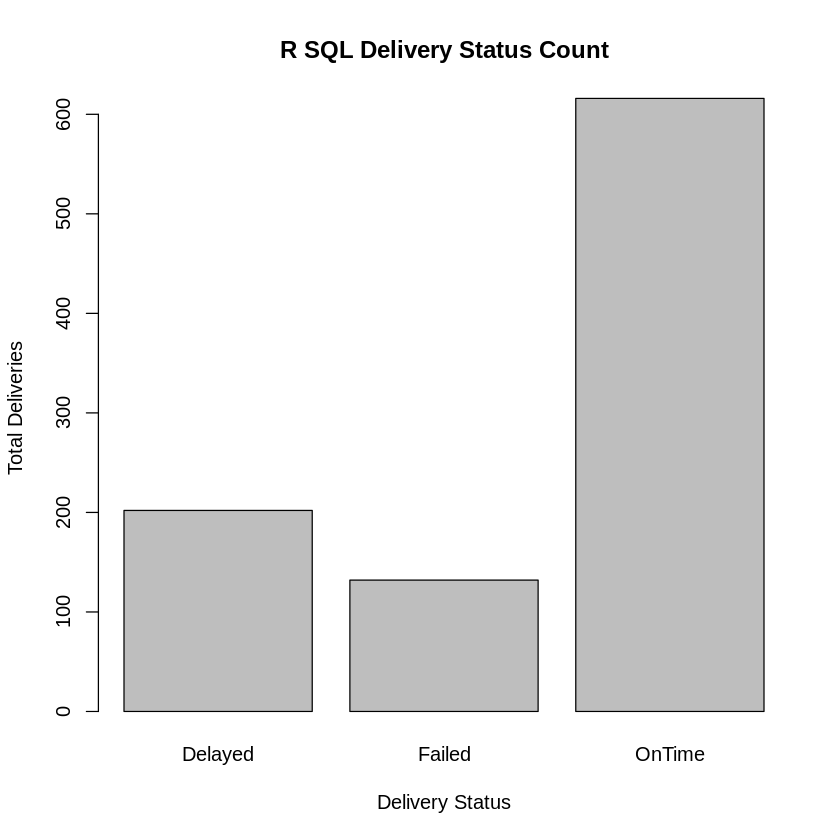

In [ ]:
delivery_status_sql <- sqldf("
SELECT delivery_status,
COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY delivery_status
")

barplot(
  delivery_status_sql$total_deliveries,
  names.arg = delivery_status_sql$delivery_status,
  main = "R SQL Delivery Status Count",
  xlab = "Delivery Status",
  ylab = "Total Deliveries"
)

### Insight
The SQL query shows the distribution of delivery outcomes. This supports the identification of delivery reliability issues within the structured operational data.

In [ ]:
sqldf("
SELECT delivery_status,
AVG(customer_rating_post_delivery) AS avg_rating
FROM deliveries
GROUP BY delivery_status
")

delivery_status,avg_rating
<chr>,<dbl>
Delayed,3.114975
Failed,3.049313
OnTime,4.283273


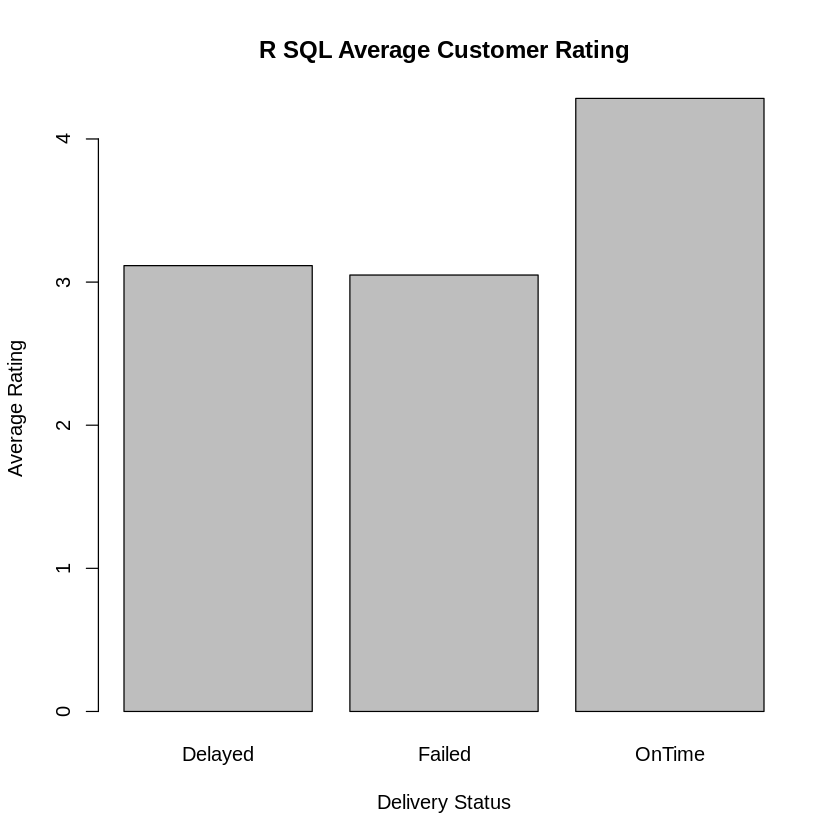

In [ ]:
rating_sql <- sqldf("
SELECT delivery_status,
AVG(customer_rating_post_delivery) AS avg_rating
FROM deliveries
GROUP BY delivery_status
")

barplot(
  rating_sql$avg_rating,
  names.arg = rating_sql$delivery_status,
  main = "R SQL Average Customer Rating",
  xlab = "Delivery Status",
  ylab = "Average Rating"
)

### Insight
Average customer ratings differ by delivery status, showing that SQL aggregation can reveal the relationship between operational performance and customer satisfaction.

In [ ]:
sqldf("
SELECT complaint_type,
COUNT(*) AS total_high_severity
FROM complaints
WHERE severity = 'High'
GROUP BY complaint_type
ORDER BY total_high_severity DESC
")

complaint_type,total_high_severity
<chr>,<int>
Delay,18
MissedPickup,16
DriverBehaviour,16
AppIssue,13
Damage,7
Billing,4
SupportExperience,3


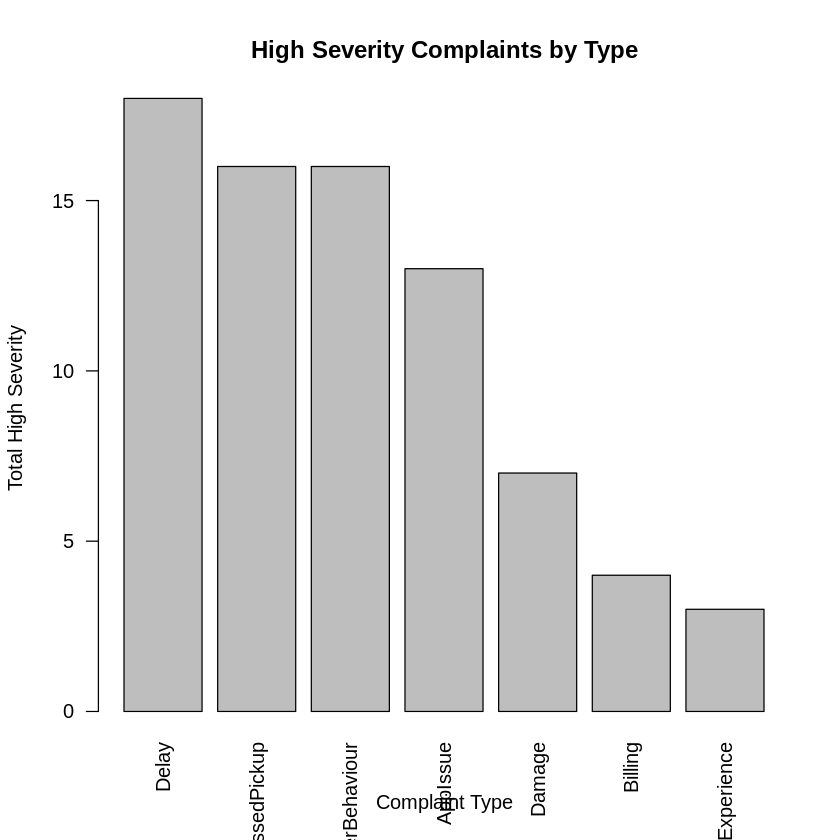

In [ ]:
high_complaints_sql <- sqldf("
SELECT complaint_type,
COUNT(*) AS total_high_severity
FROM complaints
WHERE severity = 'High'
GROUP BY complaint_type
ORDER BY total_high_severity DESC
")

barplot(
  high_complaints_sql$total_high_severity,
  names.arg = high_complaints_sql$complaint_type,
  main = "High Severity Complaints by Type",
  xlab = "Complaint Type",
  ylab = "Total High Severity",
  las = 2
)

### Insight
Filtering high-severity complaints helps identify the complaint categories that create the greatest operational and customer service risk.

In [ ]:
sqldf("
SELECT
d.delivery_status,
o.priority_level,
COUNT(*) AS total_deliveries
FROM deliveries d
JOIN orders o
ON d.order_id = o.order_id
GROUP BY d.delivery_status, o.priority_level
ORDER BY total_deliveries DESC
")

delivery_status,priority_level,total_deliveries
<chr>,<chr>,<int>
OnTime,Medium,235
OnTime,Low,172
OnTime,High,153
Delayed,Medium,88
Failed,Medium,63
OnTime,Critical,56
Delayed,Low,53
Delayed,High,46
Failed,Low,34


### Insight
The join between deliveries and orders shows how structured tables can be connected using order_id to analyse delivery performance across priority levels.

In [ ]:
sqldf("
SELECT
service_type,
AVG(order_value) AS avg_order_value
FROM orders
GROUP BY service_type
ORDER BY avg_order_value DESC
")

service_type,avg_order_value
<chr>,<dbl>
Passenger,96.07364
Business,92.24503
Retail,90.01367
Parcel,87.61565
Medical,87.13619


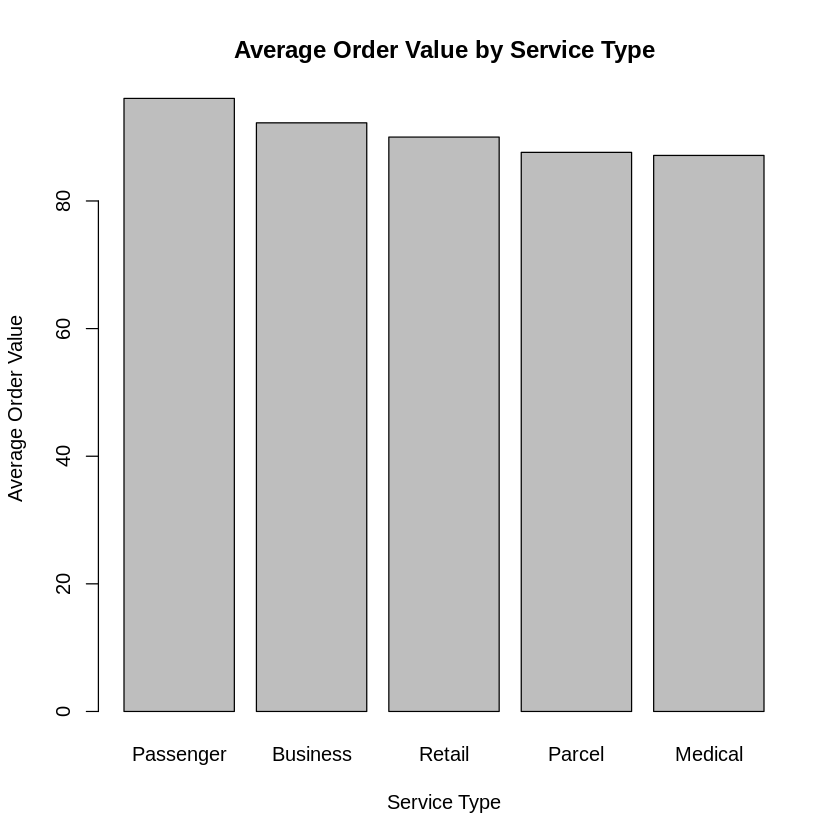

In [ ]:
order_value_sql <- sqldf("
SELECT
service_type,
AVG(order_value) AS avg_order_value
FROM orders
GROUP BY service_type
ORDER BY avg_order_value DESC
")

barplot(
  order_value_sql$avg_order_value,
  names.arg = order_value_sql$service_type,
  main = "Average Order Value by Service Type",
  xlab = "Service Type",
  ylab = "Average Order Value"
)

### Insight
Average order value differs across service types, showing which services may have stronger financial importance for NorthStar.

 ## R Visual Analytics using ggplot2

In [ ]:
install.packages("ggplot2")
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



R ANALYTICS 1 — Delivery Status Distribution

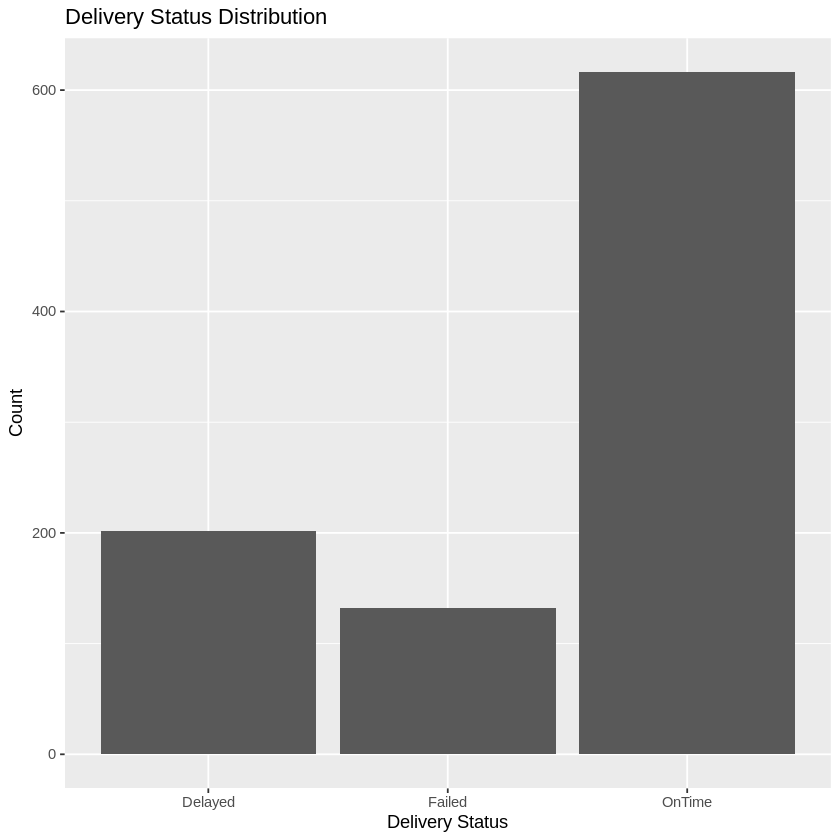

In [ ]:
ggplot(deliveries, aes(x = delivery_status)) +
  geom_bar() +
  ggtitle("Delivery Status Distribution") +
  xlab("Delivery Status") +
  ylab("Count")

R ANALYTICS 2 — Customer Rating by Delivery Status

Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


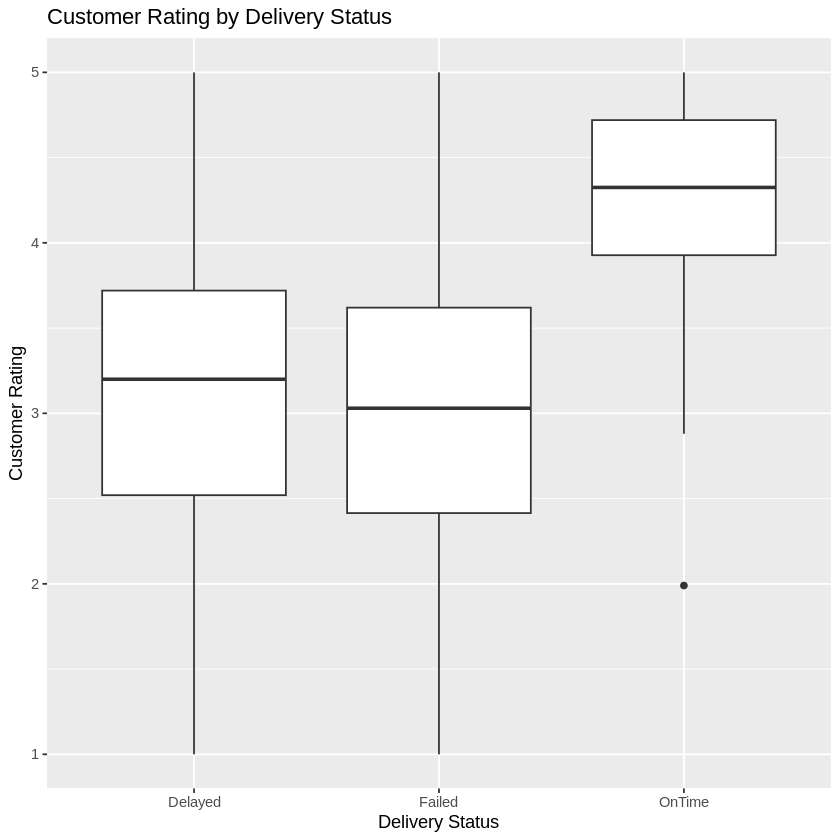

In [ ]:
ggplot(deliveries,
       aes(x = delivery_status,
           y = customer_rating_post_delivery)) +
  geom_boxplot() +
  ggtitle("Customer Rating by Delivery Status") +
  xlab("Delivery Status") +
  ylab("Customer Rating")

R ANALYTICS 3 — Complaint Severity Distribution

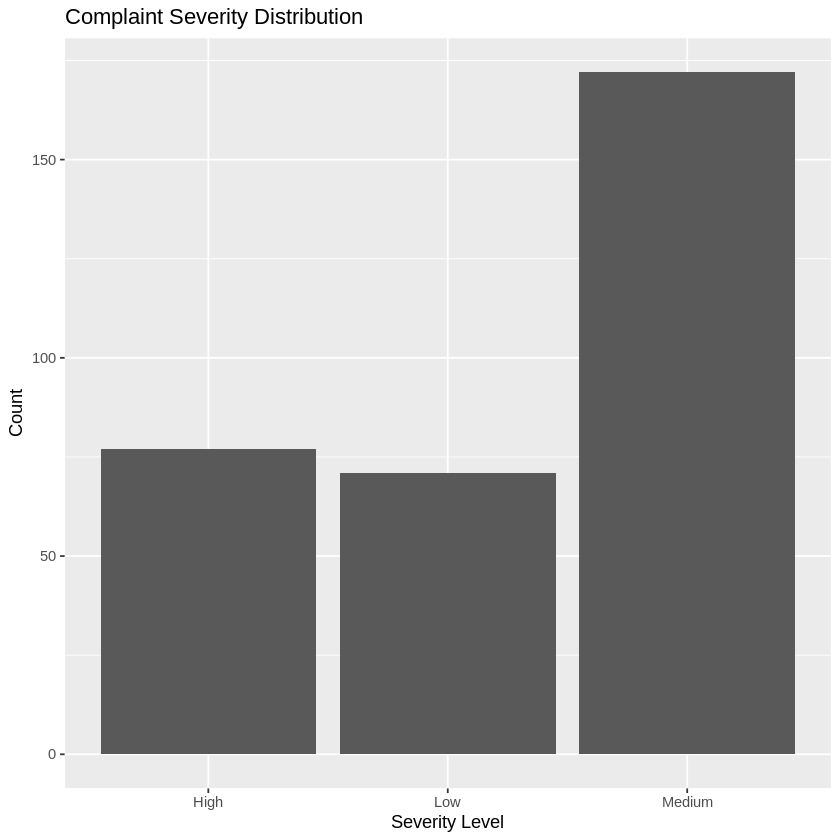

In [ ]:
ggplot(complaints, aes(x = severity)) +
  geom_bar() +
  ggtitle("Complaint Severity Distribution") +
  xlab("Severity Level") +
  ylab("Count")

R ANALYTICS 4 — Resolution Days by Severity

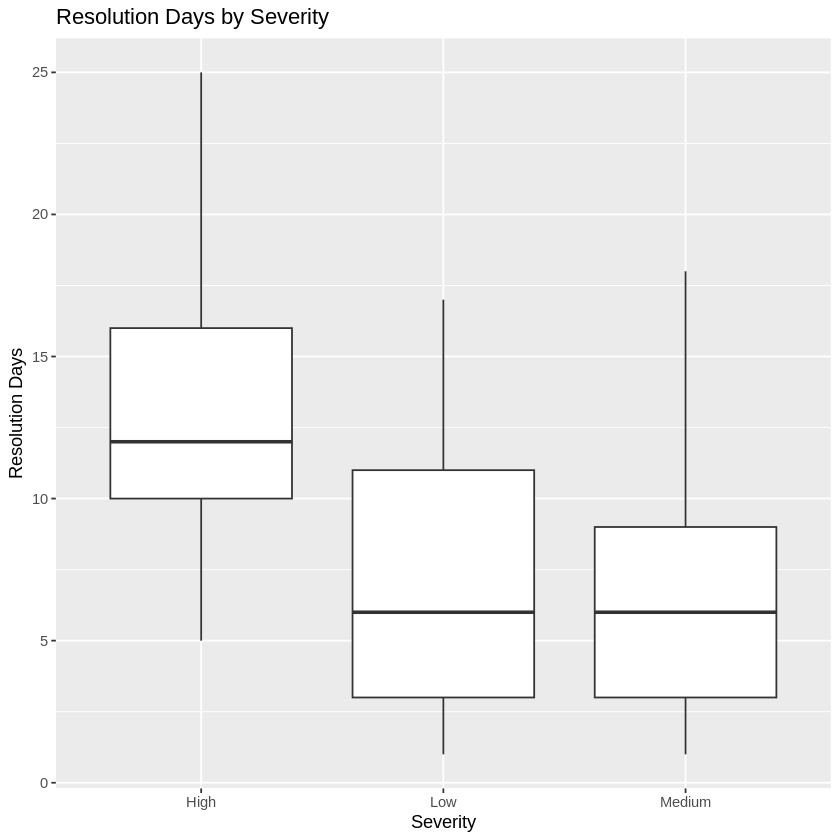

In [ ]:
ggplot(complaints,
       aes(x = severity,
           y = resolution_days)) +
  geom_boxplot() +
  ggtitle("Resolution Days by Severity") +
  xlab("Severity") +
  ylab("Resolution Days")

# Summary

This notebook demonstrated SQL querying within R using SQLDF and analytical visualisation using ggplot2.

The analysis identified delivery performance trends, customer satisfaction patterns, complaint severity distributions, and operational relationships across the NorthStar logistics environment.